In [12]:
import os
import pickle as pkl

import pandas as pd

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats



def differential_expression_analysis(output_dir, count_matrix, meta_data):

    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=count_matrix,
        metadata=meta_data,
        design_factors="condition",
        refit_cooks=True,
        inference=inference,
    )

    dds.deseq2()

    print(dds)
    print(dds.varm["dispersions"])
    print(dds.varm["LFC"])

    stat_res = DeseqStats(dds, inference=inference)
    print(stat_res.summary())
    stat_res.results_df.to_csv(os.path.join(output_dir, "results.csv"))
    return stat_res,dds




In [13]:
count_matrix = pd.read_csv('../../../data_preprocessed/count_matrix_preprocessed/final_data_without_norm.csv', index_col = 0)
count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


In [14]:
import pickle
with open('../../../data_preprocessed/pickle_file/NCI_with_No_Plaques.pkl','rb') as f:
    NCI_with_No_Plaques= pickle.load(f)

with open('../../../data_preprocessed/pickle_file/AD_with_Plaques.pkl','rb') as f:
    AD_with_Plaques= pickle.load(f)



In [15]:
NCI_with_No_Plaques = list(set(NCI_with_No_Plaques).intersection(set(count_matrix.index)))
AD_with_Plaques = list(set(AD_with_Plaques).intersection(set(count_matrix.index)))

In [16]:
count_matrix = pd.concat([count_matrix.loc[AD_with_Plaques,],count_matrix.loc[NCI_with_No_Plaques,]])
count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
350_120501,538,480,269,505,134,1330,8028,1020,502,1244,...,304,2394,7436,590,102,50,929,700,822,596
649_120529,474,473,262,474,181,1041,8290,748,457,961,...,186,1685,7331,543,99,62,1014,566,682,407
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
494_120515,410,526,320,611,168,1175,9763,1222,626,906,...,188,3032,9846,549,60,47,977,446,845,517
34_120416,297,396,292,230,139,840,4389,779,291,678,...,159,1877,4510,262,48,55,596,406,512,363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57_120417,248,268,174,174,81,704,3630,581,211,495,...,80,1835,4312,268,49,16,458,277,402,252
340_120501,574,420,387,415,198,795,6844,705,390,923,...,208,2006,8099,410,46,51,900,346,621,431
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403
72_120417,297,320,224,299,95,676,5378,793,340,624,...,106,2265,7049,295,72,15,602,251,516,266


In [17]:
labels = [ 'AD' for i in range(len(AD_with_Plaques))] + ['NCI' for j in range(len(NCI_with_No_Plaques))]
meta_data = pd.DataFrame(labels, index = count_matrix.index).rename(columns={0:'condition'})
meta_data

,condition
350_120501,AD
649_120529,AD
604_120523,AD
494_120515,AD
34_120416,AD
...,...
57_120417,NCI
340_120501,NCI
483_120515,NCI
72_120417,NCI


In [18]:
#meta_data.index = meta_data.index + '_' + meta_data.condition
#meta_data

In [19]:
stat_res,dds = differential_expression_analysis(output_dir='./', count_matrix=count_matrix, meta_data=meta_data)

Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 1.16 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 1.49 seconds.

Fitting LFCs...
... done in 0.78 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 38 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


AnnData object with n_obs × n_vars = 154 × 17330
    obs: 'condition'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'
[0.02124618 0.0163917  0.02769009 ... 0.02374994 0.00883042 0.01305545]
                 intercept  condition_NCI_vs_AD
ENSG00000101901   5.881585             0.082917
ENSG00000174839   5.887343             0.009571
ENSG00000151466   5.457046            -0.014248
ENSG00000168288   5.821221             0.045272
ENSG00000112343   4.954416            -0.033559
...                    ...                  ...
ENSG00000120457   3.740312            -0.1

... done in 0.40 seconds.



In [21]:
res = stat_res.results_df.sort_values(by = 'padj' )

In [22]:
from sanbomics.tools import id_map

In [23]:
mapper = id_map(species = 'human')

In [24]:
res['Symbol'] = res.index.map(mapper.mapper) 
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
ENSG00000154864,204.613676,-0.842375,0.110436,-7.627746,2.388927e-14,4.140011e-10,PIEZO2
ENSG00000196154,60.387656,-1.173130,0.161146,-7.279920,3.340190e-13,2.894274e-09,S100A4
ENSG00000158169,135.325783,-0.418685,0.058512,-7.155521,8.335581e-13,4.566758e-09,FANCC
ENSG00000011426,1021.971600,-0.745191,0.104614,-7.123256,1.054070e-12,4.566758e-09,ANLN
ENSG00000171388,606.693048,-0.772830,0.110769,-6.976922,3.017179e-12,1.045754e-08,APLN
...,...,...,...,...,...,...,...
ENSG00000131149,764.658605,-0.000040,0.038378,-0.001036,9.991735e-01,9.994042e-01,GSE1
ENSG00000135124,308.243109,0.000029,0.042005,0.000683,9.994552e-01,9.996282e-01,P2RX4
ENSG00000109099,1165.480027,0.000039,0.068064,0.000578,9.995386e-01,9.996539e-01,PMP22
ENSG00000100297,191.888860,0.000016,0.078866,0.000209,9.998331e-01,9.998908e-01,MCM5


In [25]:
res = res[res.baseMean >= 10]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
ENSG00000154864,204.613676,-0.842375,0.110436,-7.627746,2.388927e-14,4.140011e-10,PIEZO2
ENSG00000196154,60.387656,-1.173130,0.161146,-7.279920,3.340190e-13,2.894274e-09,S100A4
ENSG00000158169,135.325783,-0.418685,0.058512,-7.155521,8.335581e-13,4.566758e-09,FANCC
ENSG00000011426,1021.971600,-0.745191,0.104614,-7.123256,1.054070e-12,4.566758e-09,ANLN
ENSG00000171388,606.693048,-0.772830,0.110769,-6.976922,3.017179e-12,1.045754e-08,APLN
...,...,...,...,...,...,...,...
ENSG00000131149,764.658605,-0.000040,0.038378,-0.001036,9.991735e-01,9.994042e-01,GSE1
ENSG00000135124,308.243109,0.000029,0.042005,0.000683,9.994552e-01,9.996282e-01,P2RX4
ENSG00000109099,1165.480027,0.000039,0.068064,0.000578,9.995386e-01,9.996539e-01,PMP22
ENSG00000100297,191.888860,0.000016,0.078866,0.000209,9.998331e-01,9.998908e-01,MCM5


In [61]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]


In [27]:
import scanpy as sc

sc.tl.pca(dds)

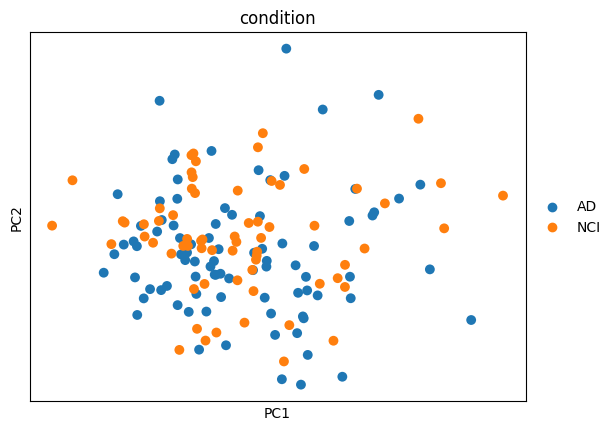

In [30]:
sc.pl.pca(dds, color = 'condition', size = 200)

In [31]:
ranking = res[['Symbol', 'stat']].dropna().sort_values('stat', ascending = False)
ranking

,Symbol,stat
ENSG00000125534,PPDPF,6.710420
ENSG00000198830,HMGN2,6.443670
ENSG00000171476,HOPX,5.954787
ENSG00000254858,MPV17L2,5.833362
ENSG00000139410,SDSL,5.673206
...,...,...
ENSG00000171388,APLN,-6.976922
ENSG00000011426,ANLN,-7.123256
ENSG00000158169,FANCC,-7.155521
ENSG00000196154,S100A4,-7.279920


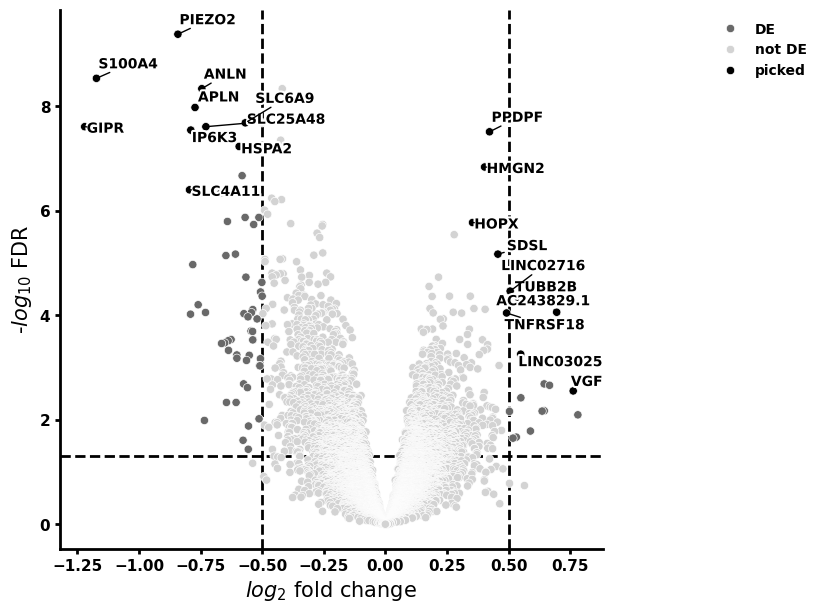

In [65]:
from sanbomics.plots import volcano
volcano(res, symbol='Symbol', to_label = 10,figsize = (7,7),log2fc_thresh=0.5, save='../../../data_preprocessed/grn_analysis_output/plots/diff_exp_plot')

In [35]:
sigs 

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
ENSG00000154864,204.613676,-0.842375,0.110436,-7.627746,2.388927e-14,4.140011e-10,PIEZO2
ENSG00000196154,60.387656,-1.173130,0.161146,-7.279920,3.340190e-13,2.894274e-09,S100A4
ENSG00000011426,1021.971600,-0.745191,0.104614,-7.123256,1.054070e-12,4.566758e-09,ANLN
ENSG00000171388,606.693048,-0.772830,0.110769,-6.976922,3.017179e-12,1.045754e-08,APLN
ENSG00000196517,421.084950,-0.568691,0.082968,-6.854368,7.162844e-12,2.059335e-08,SLC6A9
...,...,...,...,...,...,...,...
ENSG00000181577,26.597843,0.588995,0.182073,3.234942,1.216675e-03,1.643234e-02,C6orf223
ENSG00000169994,66.017244,0.531745,0.171548,3.099697,1.937187e-03,2.148600e-02,MYO7B
ENSG00000120738,830.217715,0.518238,0.168273,3.079739,2.071820e-03,2.245443e-02,EGR1
ENSG00000091879,348.567322,-0.577793,0.190494,-3.033126,2.420345e-03,2.468780e-02,ANGPT2


# Over Enrichment (GSEA)

In [67]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
from gseapy import Biomart
bm = Biomart()

•	GO Molecular Function 2023
•	MSigDB Hallmark 2020
•	KEGG 2021 (Human)
•	GO Cellular Component 2023
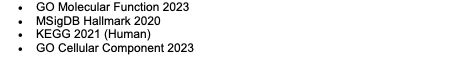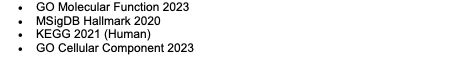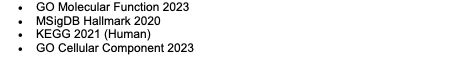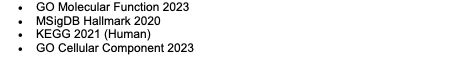


In [79]:
enr = gp.enrichr(gene_list=sigs.dropna().Symbol.tolist(), # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
enr.results[enr.results['Adjusted P-value']<=0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


In [80]:
enr.results[enr.results['Adjusted P-value']<=0.05].Term.tolist()

[]

In [81]:
enr = gp.enrichr(gene_list=sigs.dropna().Symbol.tolist(), # or "./tests/data/gene_list.txt",
                 gene_sets=['GO_Molecular_Function_2023'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
enr.results[enr.results['Adjusted P-value']<=0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Molecular_Function_2023,Hormone Activity (GO:0005179),4/74,0.000139,0.017153,0,0,16.937313,150.411879,VGF;SST;CRH;APLN
1,GO_Molecular_Function_2023,Neutral L-amino Acid:Sodium Symporter Activity...,2/7,0.000258,0.017153,0,0,115.501449,954.361803,SLC6A9;SLC38A2


In [82]:
enr.results[enr.results['Adjusted P-value']<=0.05].Term.tolist()

['Hormone Activity (GO:0005179)',
 'Neutral L-amino Acid:Sodium Symporter Activity (GO:0005295)']

In [83]:
enr = gp.enrichr(gene_list=sigs.dropna().Symbol.tolist(), # or "./tests/data/gene_list.txt",
                 gene_sets=['GO_Cellular_Component_2023'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
enr.results[enr.results['Adjusted P-value']<=0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Cellular_Component_2023,Collagen-Containing Extracellular Matrix (GO:0...,7/373,0.000354,0.018403,0,0,5.846183,46.456677,AZGP1;ANGPT2;ANGPT1;S100A4;PRELP;NPNT;FREM3
1,GO_Cellular_Component_2023,Microvillus (GO:0005902),3/58,0.001150,0.029902,0,0,15.941711,107.892131,VCAM1;ANGPT1;MYO7B


In [84]:
enr.results[enr.results['Adjusted P-value']<=0.05].Term.tolist()

['Collagen-Containing Extracellular Matrix (GO:0062023)',
 'Microvillus (GO:0005902)']

In [85]:
enr = gp.enrichr(gene_list=sigs.dropna().Symbol.tolist(), # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
enr.results[enr.results['Adjusted P-value']<=0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,5/200,0.000725,0.021036,0,0,7.666667,55.420917,EGR1;MAFF;TRIP10;GEM;ICOSLG


In [86]:
enr.results[enr.results['Adjusted P-value']<=0.05].Term.tolist()

['TNF-alpha Signaling via NF-kB']

#### ['TNF-alpha Signaling via NF-kB'], ['Collagen-Containing Extracellular Matrix (GO:0062023)','Microvillus (GO:0005902)'], ['Hormone Activity (GO:0005179)', 'Neutral L-amino Acid:Sodium Symporter Activity (GO:0005295)']


In [54]:
l = [
 'ENSG00000166823_ENSG00000178199',
 'ENSG00000157557_ENSG00000121903',

 'ENSG00000028277_ENSG00000039139',
 'ENSG00000081059_ENSG00000255561',
 'ENSG00000167981_ENSG00000143222',
 'ENSG00000198482_ENSG00000156219',
 'ENSG00000188786_ENSG00000083799',
 'ENSG00000168874_ENSG00000139197',
 'ENSG00000139800_ENSG00000150175',
 'ENSG00000079432_ENSG00000214425',
 'ENSG00000162992_ENSG00000139197',
 'ENSG00000256294_ENSG00000272576',
 'ENSG00000169635_ENSG00000234841',
 'ENSG00000125850_ENSG00000198783',
 'ENSG00000078900_ENSG00000062096',
 'ENSG00000120837_ENSG00000123179',
 'ENSG00000079432_ENSG00000188234',
 'ENSG00000188786_ENSG00000162384',
 'ENSG00000251369_ENSG00000265018',
 'ENSG00000234284_ENSG00000149089',
 'ENSG00000198429_ENSG00000107262',]

In [55]:
relevant_genes = []
for i in l:
    relevant_genes.append(i.split('_')[0])
    relevant_genes.append(i.split('_')[1])

In [56]:
len(set(relevant_genes))

39

In [57]:
set(sigs.index).intersection(set(relevant_genes))

{'ENSG00000150175'}

In [59]:
set(relevant_genes)

{'ENSG00000028277',
 'ENSG00000039139',
 'ENSG00000062096',
 'ENSG00000078900',
 'ENSG00000079432',
 'ENSG00000081059',
 'ENSG00000083799',
 'ENSG00000107262',
 'ENSG00000120837',
 'ENSG00000121903',
 'ENSG00000123179',
 'ENSG00000125850',
 'ENSG00000139197',
 'ENSG00000139800',
 'ENSG00000143222',
 'ENSG00000149089',
 'ENSG00000150175',
 'ENSG00000156219',
 'ENSG00000157557',
 'ENSG00000162384',
 'ENSG00000162992',
 'ENSG00000166823',
 'ENSG00000167981',
 'ENSG00000168874',
 'ENSG00000169635',
 'ENSG00000178199',
 'ENSG00000188234',
 'ENSG00000188786',
 'ENSG00000198429',
 'ENSG00000198482',
 'ENSG00000198783',
 'ENSG00000214425',
 'ENSG00000234284',
 'ENSG00000234841',
 'ENSG00000251369',
 'ENSG00000255561',
 'ENSG00000256294',
 'ENSG00000265018',
 'ENSG00000272576'}

In [66]:
len(set(sigs.index.tolist()))

74